In [57]:
import yaml
import numpy as np
from dotmap import DotMap
import matplotlib.pyplot as plt

#### Load the evaluation configuration

In [58]:
config_file = "runs_debug/UVFDDPG/CenterDot/job_530956.centerdot/2024-07-30-16-52-28/lag/2024-07-30-21-31-48/bk/bk_config.yaml"
with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
config = DotMap(config)
trained_cost_limit = config.agent.cost_limit

#### Extract the metrics from records

In [59]:
def extract_single_agent_metrics(records):
    success_rate = 0.0
    steps = []
    rewards = []
    cumulative_costs = []
    for record in records:
        if record["cumulative_costs"] < trained_cost_limit:
            if record["success"]:
                success_rate += 1
        steps.append(record["steps"])
        rewards.append(record["rewards"])
        cumulative_costs.append(record["cumulative_costs"])

    metrics = {
        'steps': steps,
        'rewards': rewards,
        'cumulative_costs': cumulative_costs, 
        'success_rate': success_rate / len(records),
    }
    return metrics

In [60]:
def extract_multi_agent_metrics(records, num_agents):
    success_rate = 0.0
    mean_steps = []
    mean_rewards = []
    mean_cumulative_costs = []
    for record in records:
        steps = []
        rewards = []
        successes = []
        cumulative_costs = []
        for i in range(num_agents):
            steps.append(record[i]["steps"])
            rewards.append(record[i]["rewards"])
            successes.append(record[i]["success"])
            cumulative_costs.append(record[i]["cumulative_costs"])
        all_success = all(successes)
        all_within_cost_limit = all([cost < trained_cost_limit for cost in cumulative_costs])
        if all_success and all_within_cost_limit:
            success_rate += 1
        
        mean_steps.append(np.mean(steps))
        mean_rewards.append(np.mean(rewards))
        mean_cumulative_costs.append(np.mean(cumulative_costs))

    metrics = {
        'mean_steps': mean_steps,
        'mean_rewards': mean_rewards,
        'mean_cumulative_costs': mean_cumulative_costs,
        'success_rate': success_rate / len(records),
    }

    return metrics

## Single-Agent Comparisons

In [61]:
unconstrained_records = np.load("pud/plots/data/single_agent/unconstrained_records.npy", allow_pickle=True)
unconstrained_search_records = np.load("pud/plots/data/single_agent/unconstrained_search_records.npy", allow_pickle=True)
constrained_records = np.load("pud/plots/data/single_agent/constrained_records.npy", allow_pickle=True)
constrained_search_factored_records = np.load("pud/plots/data/single_agent/constrained_search_factored_records.npy", allow_pickle=True)

unconstrained_metrics = extract_single_agent_metrics(unconstrained_records)
unconstrained_search_metrics = extract_single_agent_metrics(unconstrained_search_records)
constrained_metrics = extract_single_agent_metrics(constrained_records)
constrained_search_factored_metrics = [extract_single_agent_metrics(csr) for csr in constrained_search_factored_records]

In [62]:
def plot_success_rate(metrics):
    unconstrained_sr = metrics[0]['success_rate']
    unconstrained_search_sr = metrics[1]['success_rate']
    constrained_sr = metrics[2]['success_rate']
    constrained_search_srates = [metric["success_rate"] for metric in metrics[3]]

    _, ax = plt.subplots(figsize=(8, 5))

    ax.bar(
        ['Unconstrained', 'Unconstrained\nSearch', 'Constrained', 'Constrained\nSearch (0.25)', 'Constrained\nSearch (0.5)', 'Constrained\nSearch (0.75)', 'Constrained\nSearch (1.0)'],
        [unconstrained_sr, unconstrained_search_sr, constrained_sr, *constrained_search_srates],
        color=['pink', 'lightblue', 'lightgreen', 'orange', 'gold', 'tomato', 'peachpuff'],
    )
    ax.set_ylim(0, 1)
    ax.set_xlabel('Method')
    ax.set_title(f'Success Rate (Cost Limit = {trained_cost_limit})')
    ax.set_ylabel('Success Rate')

    plt.tight_layout()
    plt.show()

In [63]:
def plot_bplots(data, labels, plot_params):
    _, ax = plt.subplots(figsize=(8, 5))

    bplot = ax.boxplot(data, vert=True, notch=False, patch_artist=True, showfliers=False)
    colors=['pink', 'lightblue', 'lightgreen', 'orange', 'gold', 'tomato', 'peachpuff']
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)  # type: ignore

    ax.yaxis.grid(True)
    ax.set_title(plot_params['title'], fontsize=16)
    ax.set_ylabel(plot_params['ylabel'], fontsize=12)
    ax.set_xlabel(plot_params['xlabel'], fontsize=12)
    ax.set_xticklabels(labels)

    if 'trained_cost_limit' in plot_params:
        ax.axhline(y=plot_params['trained_cost_limit'], color='k')

    plt.tight_layout()
    plt.show()

In [64]:
def plot_steps(metrics, num_agents):
    key = 'mean_steps' if num_agents > 1 else 'steps'
    unconstrained_steps = metrics[0][key]
    unconstrained_search_steps = metrics[1][key]
    constrained_steps = metrics[2][key]
    constrained_search_steps = [metric[key] for metric in metrics[3]]

    plot_bplots(
        [unconstrained_steps, unconstrained_search_steps, constrained_steps, *constrained_search_steps],
        ['Unconstrained', 'Unconstrained\nSearch', 'Constrained', 'Constrained\nSearch (0.25)', 'Constrained\nSearch (0.5)', 'Constrained\nSearch (0.75)', 'Constrained\nSearch (1.0)'],
        {'title': f'Steps (|A| = {num_agents}, Cost Limit: {trained_cost_limit})', 'ylabel': 'Steps', 'xlabel': 'Method'}
    )

In [65]:
def plot_rewards(metrics, num_agents):
    key = 'mean_rewards' if num_agents > 1 else 'rewards'
    unconstrained_rewards = metrics[0][key]
    unconstrained_search_rewards = metrics[1][key]
    constrained_rewards = metrics[2][key]
    constrained_search_rewards = [metric[key] for metric in metrics[3]]

    plot_bplots(
        [unconstrained_rewards, unconstrained_search_rewards, constrained_rewards, *constrained_search_rewards],
        ['Unconstrained', 'Unconstrained\nSearch', 'Constrained', 'Constrained\nSearch (0.25)', 'Constrained\nSearch (0.5)', 'Constrained\nSearch (0.75)', 'Constrained\nSearch (1.0)'],
        {'title': f'Rewards (|A| = {num_agents}, Cost Limit: {trained_cost_limit})', 'ylabel': 'Rewards', 'xlabel': 'Method'}
    )

In [66]:
def plot_cumulative_costs(metrics, num_agents):
    key = 'mean_cumulative_costs' if num_agents > 1 else 'cumulative_costs'
    unconstrained_cc = metrics[0][key]
    unconstrained_search_cc = metrics[1][key]
    constrained_cc = metrics[2][key]
    constrained_search_cc = [metric[key] for metric in metrics[3]]

    plot_bplots(
        [unconstrained_cc, unconstrained_search_cc, constrained_cc, *constrained_search_cc],
        ['Unconstrained', 'Unconstrained\nSearch', 'Constrained', 'Constrained\nSearch (0.25)', 'Constrained\nSearch (0.5)', 'Constrained\nSearch (0.75)', 'Constrained\nSearch (1.0)'],
        {'title': f'Cumulative Costs (|A| = {num_agents}, Cost Limit: {trained_cost_limit})', 'ylabel': 'Cumulative Costs', 'xlabel': 'Method', 'trained_cost_limit': trained_cost_limit}
    )

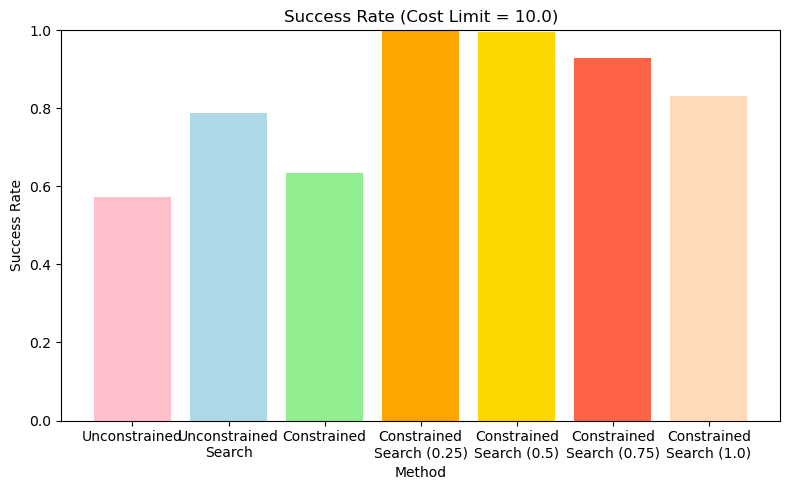

In [67]:
plot_success_rate([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics])

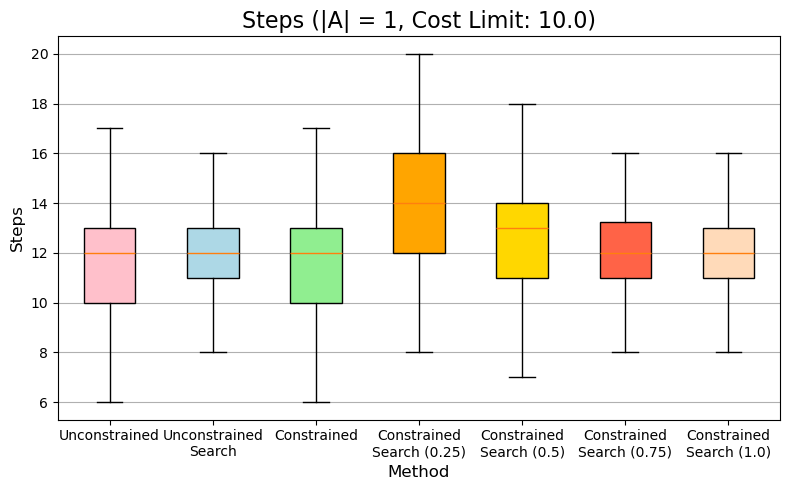

In [68]:
plot_steps([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics], 1)

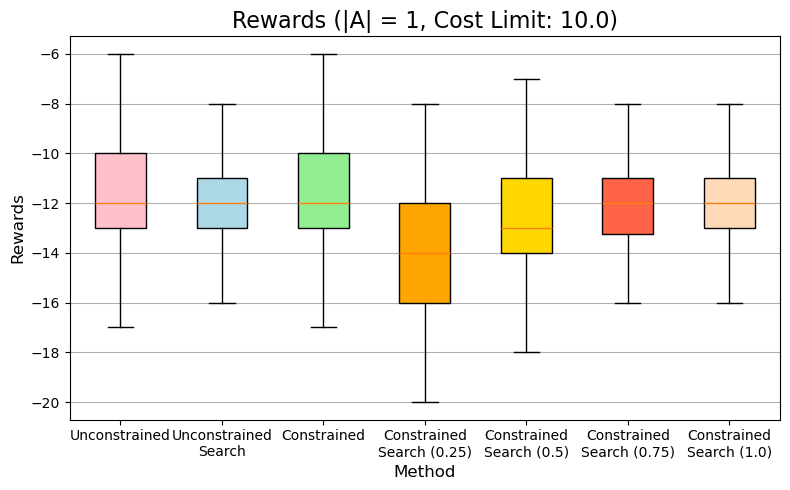

In [69]:
plot_rewards([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics], 1)

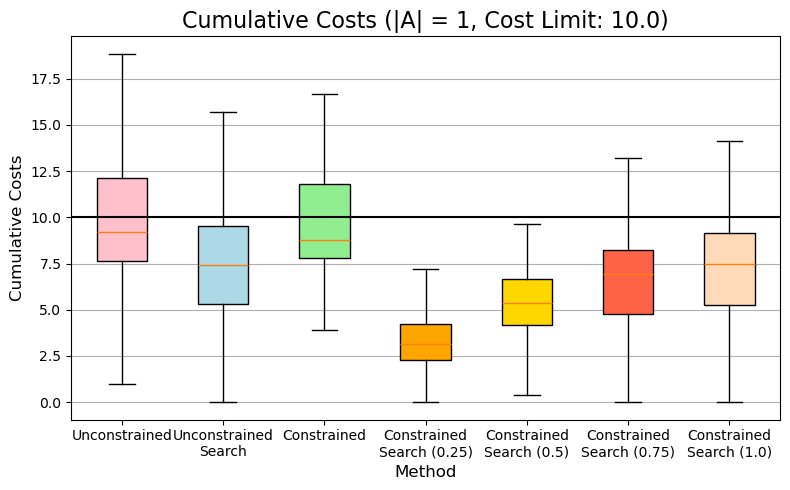

In [70]:
plot_cumulative_costs([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics], 1)

In [71]:
unconstrained_records = np.load("pud/plots/data/multi_agent/unconstrained_records_2.npy", allow_pickle=True)
unconstrained_search_records = np.load("pud/plots/data/multi_agent/unconstrained_search_records_2.npy", allow_pickle=True)
constrained_records = np.load("pud/plots/data/multi_agent/constrained_records_2.npy", allow_pickle=True)
constrained_search_factored_records = np.load("pud/plots/data/multi_agent/constrained_search_factored_records_2.npy", allow_pickle=True)

unconstrained_metrics = extract_multi_agent_metrics(unconstrained_records, 2)
unconstrained_search_metrics = extract_multi_agent_metrics(unconstrained_search_records, 2)
constrained_metrics = extract_multi_agent_metrics(constrained_records, 2)
constrained_search_factored_metrics = [extract_multi_agent_metrics(csr, 2) for csr in constrained_search_factored_records]

In [72]:
def plot_ma_success_rate(metrics):
    unconstrained_sr = metrics[0]['success_rate']
    unconstrained_search_sr = metrics[1]['success_rate']
    constrained_sr = metrics[2]['success_rate']

    _, ax = plt.subplots(figsize=(7, 5))

    ax.bar(
        ['Unconstrained', 'Unconstrained\nSearch', 'Constrained'],
        [unconstrained_sr, unconstrained_search_sr, constrained_sr],
        color=['pink', 'lightblue', 'lightgreen'],
    )
    ax.set_ylim(0, 1)
    ax.set_xlabel('Method')
    ax.set_title(f'Success Rate (Cost Limit = {trained_cost_limit})')
    ax.set_ylabel('Success Rate')

    plt.tight_layout()
    plt.show()

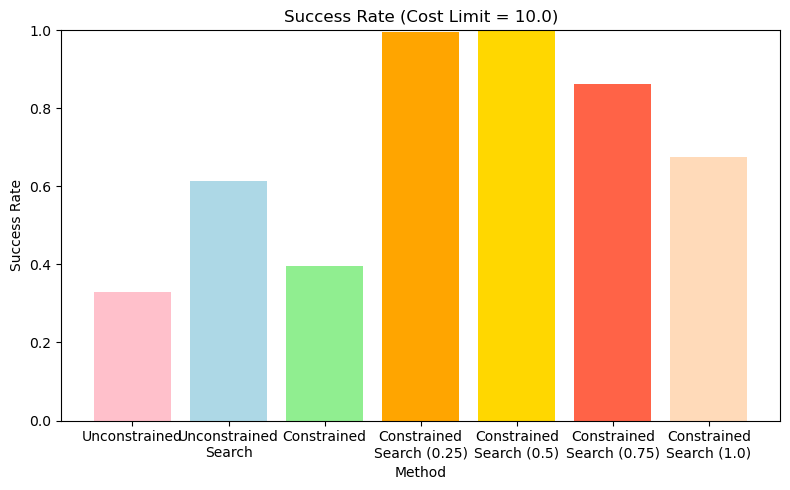

In [73]:
plot_success_rate([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics])

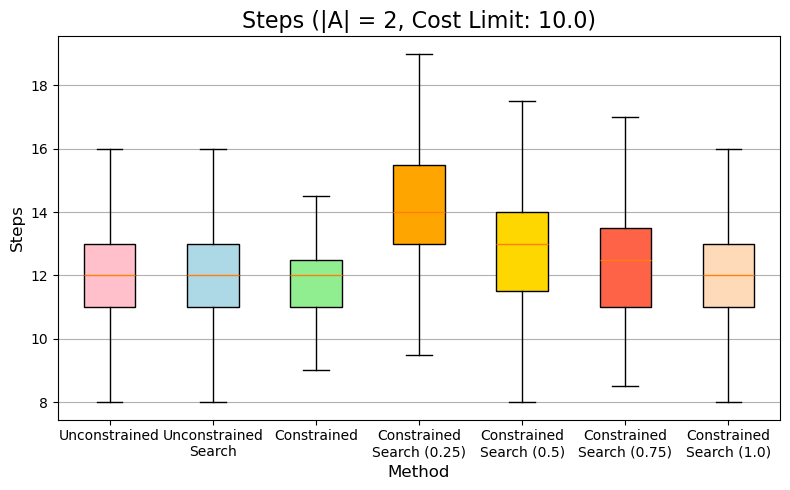

In [74]:
plot_steps([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics], 2)

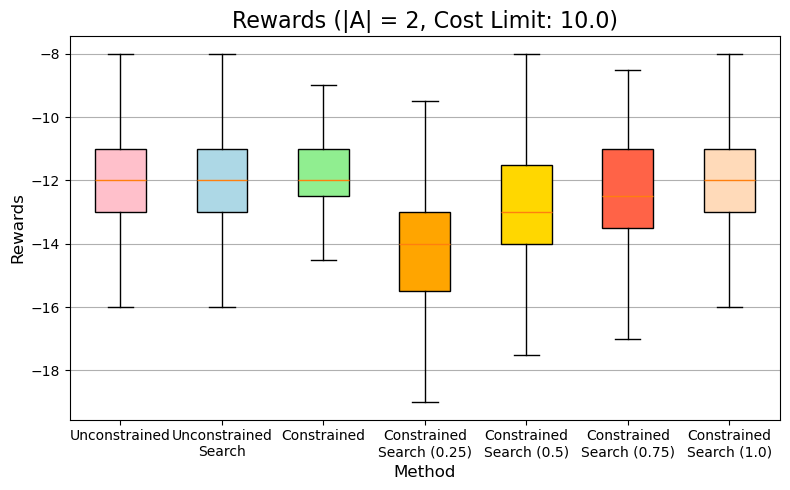

In [75]:
plot_rewards([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics], 2)

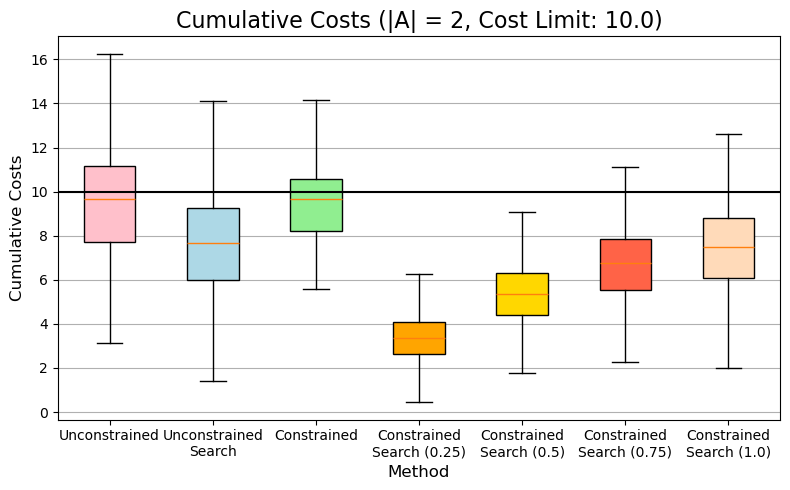

In [76]:
plot_cumulative_costs([unconstrained_metrics, unconstrained_search_metrics, constrained_metrics, constrained_search_factored_metrics], 2)